**Exercise 6.4**

MNIST with fully connected networks and grid/random search

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tabulate import tabulate
from tensorflow.keras import layers

plt.style.use("seaborn-v0_8")

The MNIST data base of handwritten numbers is directly available through KERAS. The following codeblocks download and preprocess the data.

In [2]:
with np.load('../datasets/mnist.npz') as f:
    x_train, y_train = f['x_train'], f['y_train']
    x_test, y_test = f['x_test'], f['y_test']

x_valid = x_test[8000:]
y_valid = y_test[8000:]
x_test = x_test[:8000]
y_test = y_test[:8000]

# Hint: convert integer RGB values (0-255) to float values (0-1)
x_train = np.float32(x_train) / 255
x_valid = np.float32(x_valid) / 255
x_test = np.float32(x_test) / 255

In [3]:
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_valid.shape[0], "validation samples")
print(x_test.shape[0], "test samples")

x_train shape: (60000, 28, 28)
60000 train samples
2000 validation samples
8000 test samples


In this exercise, a fully connected neural network is used to predict the handwritten numbers. To do this, we reformat the pictures with 28x28 pixels into a vector with a length of 28x28=784.

In [4]:
# reshape the image matrices to vectors
x_train = x_train.reshape(-1, 28**2)
x_valid = x_valid.reshape(-1, 28**2)
x_test = x_test.reshape(-1, 28**2)
print("x_train shape:", x_train.shape)

x_train shape: (60000, 784)


We use "onehot" encoding of the classes. This means a "zero" is encoded as `[1,0,0,0,0,0,0,0,0,0]` and a "one" as `[0,1,0,0,0,0,0,0,0,0]` etc.
This is done because our network will have ten output nodes with the output node with the largest value being the predicted number.

In [5]:
# convert class vectors to binary class matrices (10 numbers/classes)
y_train_onehot = tf.keras.utils.to_categorical(y_train, 10)
y_valid_onehot = tf.keras.utils.to_categorical(y_valid, 10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)

Here we define the model. It is a fully connected netwrok with one hidden layer of 128 neurons, a ReLU activation function, a dropout layer of 20%. After the output layer, we use the softmax activation function that allows to interpret the final output as the probabilities of the image corresponding to each digit.

In [30]:
# define model here
model = tf.keras.models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10),
    # softmax activation to transform output into probabilities
    layers.Activation('softmax')])

print(model.summary())

Model: "sequential_205"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_410 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_205 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_411 (Dense)               │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_205 (Activation)     │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

None


Now, we train the model. We use the categorical cross-entropy as the loss function (usual in classification tasks), a learning rate of $1\times10^{-3}$ (Adam optimizer default value) and a batch size of 32. We quantify the performance of the model with the accuracy.

In [7]:
model.compile(
    # the recommended loss for a classification task is 'categorical_crossentropy'
    # (see lecture for details)
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']) # we use accuracy to quanitfy to network performance.

# define callbacks for training
save_best = tf.keras.callbacks.ModelCheckpoint(
    "checkpoints/best_model_{}.weights.h5".format(model.name),
    save_best_only=True,
    monitor="val_accuracy",
    save_weights_only=True,
)

# Keras calculates training accuracy and loss during the training and
# with regularization applied, while the validation metrics are calculated
# at the end of each epoch. This callback calculates the training metrics
# the same way as for the validation
class CalculateMetrics(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        train_loss, train_acc = model.evaluate(x_train, y_train_onehot, verbose=0)
        logs["train_loss"] = train_loss
        logs["train_acc"] = train_acc

results = model.fit(
    x_train, y_train_onehot,
    validation_data=(x_valid, y_valid_onehot),

    batch_size=32,
    epochs=10,
    callbacks=[
        save_best,
        CalculateMetrics(),
        tf.keras.callbacks.CSVLogger("checkpoints/history_{}.csv".format(model.name))
    ]
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9122 - loss: 0.3040 - val_accuracy: 0.9700 - val_loss: 0.0950 - train_loss: 0.1360 - train_acc: 0.9619
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9567 - loss: 0.1470 - val_accuracy: 0.9770 - val_loss: 0.0758 - train_loss: 0.0941 - train_acc: 0.9722
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9655 - loss: 0.1098 - val_accuracy: 0.9805 - val_loss: 0.0611 - train_loss: 0.0653 - train_acc: 0.9809
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9720 - loss: 0.0901 - val_accuracy: 0.9820 - val_loss: 0.0600 - train_loss: 0.0538 - train_acc: 0.9837
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9761 - loss: 0.0752 - val_accuracy: 0.9850 - val_loss: 0.0508 - train_loss: 0.0448 - train_acc: 0.9864
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9786 - loss: 0.0677 - val_accuracy: 0.9790 - val_loss: 0.0582 - train_loss: 0

Now we plot the loss function and the accuracy for the training and the validation dataset, and the total loss.

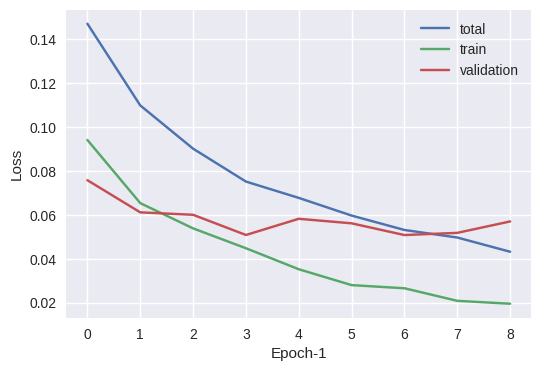

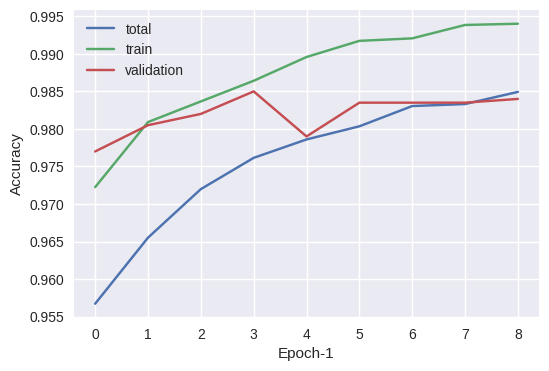

In [8]:
# load best model
model.load_weights(f"checkpoints/best_model_{model.name}.weights.h5")

# ------------------------
# ---     Plotting     ---
# ------------------------

# plot training history
history = np.genfromtxt(f"checkpoints/history_{model.name}.csv", delimiter=",", names=True)
# add plots below
loss = history["loss"][1:]
train_loss = history["train_loss"][1:]
test_loss = history["val_loss"][1:]

acc = history["accuracy"][1:]
train_acc = history["train_acc"][1:]
test_acc = history["val_accuracy"][1:]

# Plot loss over time
plt.figure(figsize=(6, 4))
plt.plot(loss, label="total")
plt.plot(train_loss,label="train")
plt.plot(test_loss,label="validation")
plt.legend()
plt.xlabel("Epoch-1")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(acc, label="total")
plt.plot(train_acc,label="train")
plt.plot(test_acc,label="validation")
plt.legend()
plt.xlabel("Epoch-1")
plt.ylabel("Accuracy")
plt.show()


We can see a bit of overfitting, since after the first 4 epochs the validation loss does not decrease anymore (and the validation accuracy does not increase as well).

In [9]:
# evaluate performance
print("Model performance :")
headers = ["", "Loss", "Accuracy", "Test error rate [%]"]

table = [
    [
        "Train",
        *model.evaluate(x_train, y_train_onehot, verbose=0, batch_size=128),
        (1 - model.evaluate(x_train, y_train_onehot, verbose=0, batch_size=128)[1])
        * 100,
    ],
    [
        "Validation",
        *model.evaluate(x_valid, y_valid_onehot, verbose=0, batch_size=128),
        (1 - model.evaluate(x_valid, y_valid_onehot, verbose=0, batch_size=128)[1])
        * 100,
    ],
    [
        "Test",
        *model.evaluate(x_test, y_test_onehot, verbose=0, batch_size=128),
        (1 - model.evaluate(x_test, y_test_onehot, verbose=0, batch_size=128)[1]) * 100,
    ],
]

print(tabulate(table, headers=headers, tablefmt="orgtbl"))

Model performance :
|            |      Loss |   Accuracy |   Test error rate [%] |
|------------+-----------+------------+-----------------------|
| Train      | 0.0448049 |   0.986417 |               1.35834 |
| Validation | 0.0508416 |   0.985    |               1.5     |
| Test       | 0.0874379 |   0.97275  |               2.725   |


The accuracy of the model is around 97% for the test dataset.

The following codeblocks define some helper functions for plotting. You don't need to touch them

In [10]:
# @title
def plot_image(X, ax=None):
    """Plot an image X.

    Args:
        X (2D array): image, grayscale or RGB
        ax (None, optional): Description
    """
    if ax is None:
        ax = plt.gca()

    if (X.ndim == 2) or (X.shape[-1] == 1):
        ax.imshow(X.astype("uint8"), origin="upper", cmap=plt.cm.Greys)
    else:
        ax.imshow(X.astype("uint8"), origin="upper")

    ax.set(xticks=[], yticks=[])


def plot_prediction(Yp, X, y, classes=None, top_n=False):
    """Plot an image along with all or the top_n predictions.

    Args:
        Yp (1D array): predicted probabilities for each class
        X (2D array): image
        y (integer): true class label
        classes (1D array, optional): class names
        top_n (int, optional): number of top predictions to show
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3.2))
    fig.subplots_adjust(left=0.02, right=0.98, bottom=0.15, top=0.98, wspace=0.02)
    plot_image(X, ax1)

    if top_n:
        n = top_n
        s = np.argsort(Yp)[-top_n:]
    else:
        n = len(Yp)
        s = np.arange(n)[::-1]

    patches = ax2.barh(np.arange(n), Yp[s], align="center")
    ax2.set(xlim=(0, 1), xlabel="Probability", yticks=[])

    for iy, patch in zip(s, patches):
        if iy == y:
            patch.set_facecolor("C1")  # color correct patch

    if classes is None:
        classes = np.arange(0, np.size(Yp))

    for i in range(n):
        ax2.text(0.05, i, classes[s][i], ha="left", va="center")

    plt.show()


def plot_confusion(yp, y, classes=None, fname=None):
    """Plot confusion matrix for given true and predicted class labels

    Args:
        yp (1D array): predicted class labels
        y (1D array): true class labels
        classes (1D array): class names
        fname (str, optional): filename for saving the plot
    """
    if classes is None:
        n = max(max(yp), max(y)) + 1
        classes = np.arange(n)
    else:
        n = len(classes)

    bins = np.linspace(-0.5, n - 0.5, n + 1)
    C = np.histogram2d(y, yp, bins=bins)[0]
    C = C / np.sum(C, axis=0) * 100

    _ = plt.figure(figsize=(8, 8))
    plt.imshow(C, interpolation="nearest", vmin=0, vmax=100, cmap=plt.cm.YlGnBu)
    plt.gca().set_aspect("equal")
    cbar = plt.colorbar(shrink=0.8)
    cbar.set_label("Frequency %")
    plt.xlabel("Prediction")
    plt.ylabel("Truth")
    plt.xticks(range(n), classes, rotation="vertical")
    plt.yticks(range(n), classes)
    for x in range(n):
        for y in range(n):
            if np.isnan(C[x, y]):
                continue
            color = "white" if x == y else "black"
            plt.annotate(
                "%.1f" % (C[x, y]), xy=(y, x), color=color, ha="center", va="center"
            )

    plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


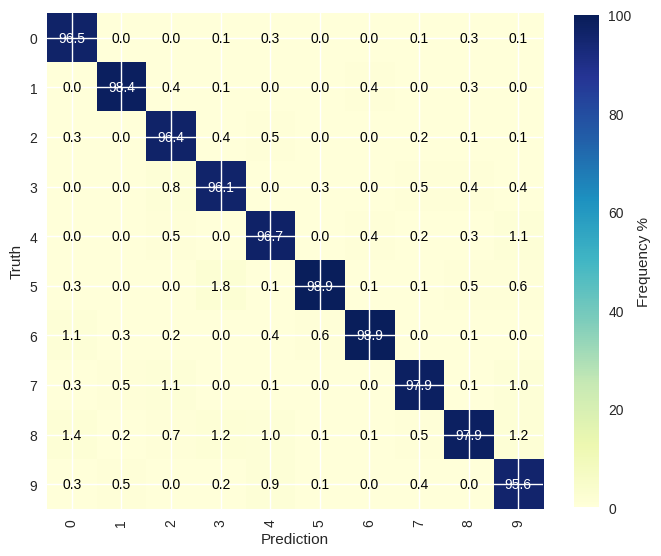

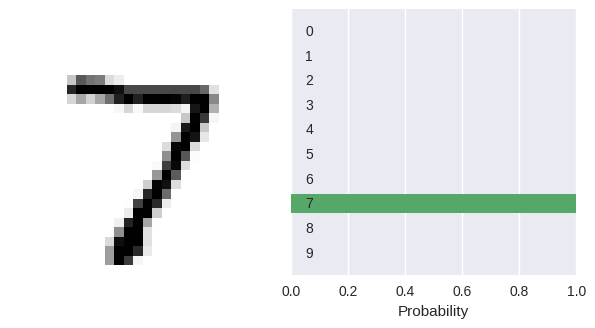

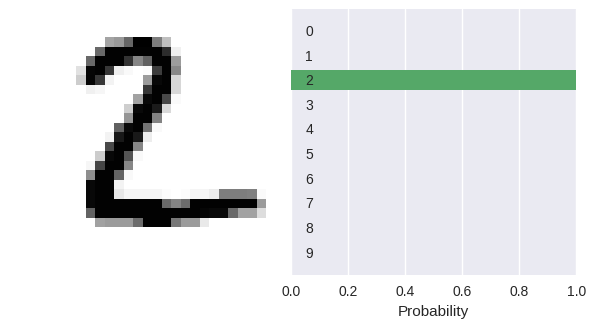

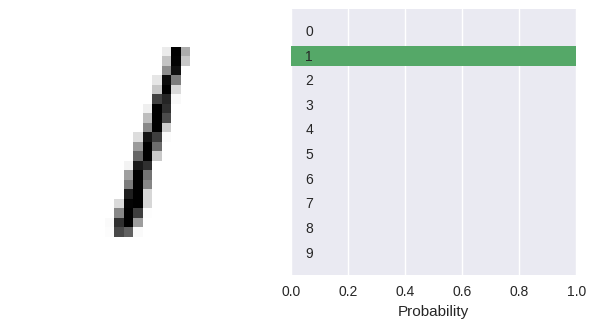

In [11]:
# plot a few examples, loop over test dataset:
# get missidentified samples
output = model.predict(x_test, batch_size=128)
labels = np.argmax(y_test_onehot, axis=1)
predictions = np.argmax(output, axis=1)
plot_confusion(predictions, labels)

for i in range(3): # loop over first 10 test samples
    plot_prediction(output[i],
                    255 * np.reshape(x_test[i], (28, 28)), # we need to reshape the data into an image and convert back to RGB color scale by multiplying with 255
                    labels[i])


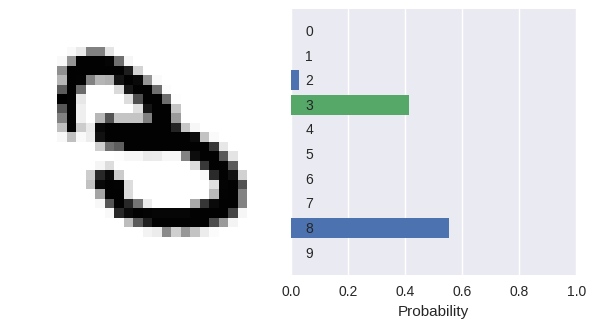

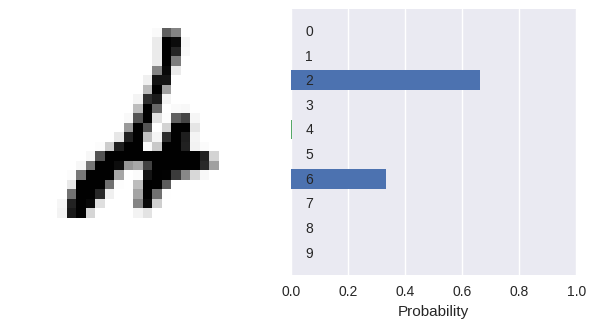

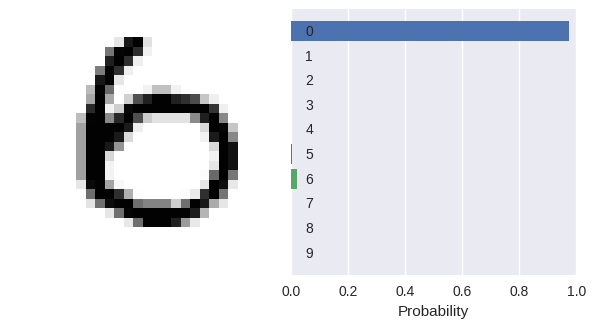

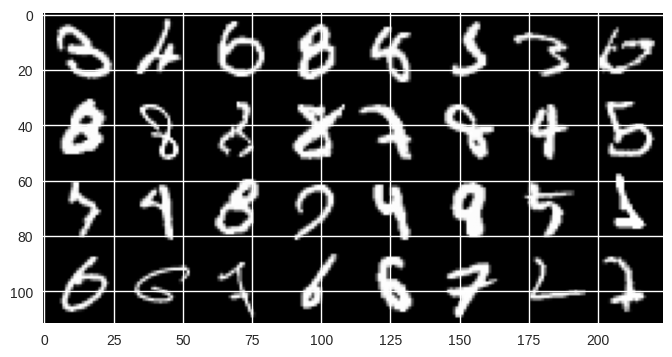

In [12]:
# now plot a few examples that were misclassified

indices_miss = np.nonzero(predictions != labels)[0]
x_missid = x_test[indices_miss]

for i in indices_miss[:3]:
    plot_prediction(output[i],
                    255 * np.reshape(x_test[i], (28, 28)), # we need to reshape the data into an image and convert back to RGB color scale by multiplying with 255
                    labels[i])

# or plot 32 of them in a joint plot
fig = plt.figure()
ax = fig.add_subplot(111)
plotdata = x_missid[:32]
plotdata = np.hstack(np.concatenate(np.reshape(plotdata, (4, 8, 28, 28)), axis=1))
ax.imshow(plotdata, cmap="gray")


We can see that the misclassified images have shapes that are not very clear and resemble other digits. For example, a 6 with a very short tail is easily mistaken for a 0. 

We now try to modify the model to get better results.

Model: "sequential_210"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_428 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_218 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_429 (Dense)               │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_219 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_430 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_220 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_431 (Dense)               │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_210 (Activation)     │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,690 (655.04 KB)

 Trainable params: 167,690 (655.04 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9071 - loss: 0.3055 - val_accuracy: 0.9670 - val_loss: 0.1052 - train_loss: 0.1264 - train_acc: 0.9616
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9548 - loss: 0.1550 - val_accuracy: 0.9785 - val_loss: 0.0698 - train_loss: 0.0767 - train_acc: 0.9763
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9638 - loss: 0.1220 - val_accuracy: 0.9765 - val_loss: 0.0740 - train_loss: 0.0808 - train_acc: 0.9754
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9682 - loss: 0.1059 - val_accuracy: 0.9815 - val_loss: 0.0620 - train_loss: 0.0552 - train_acc: 0.9831
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9710 - loss: 0.0954 - val_accuracy: 0.9850 - val_loss: 0.0613 - train_loss: 0.0388 - train_acc: 0.9879
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9743 - loss: 0.0847 - val_accuracy: 0.9810 - val_loss: 0.0615 - train_lo

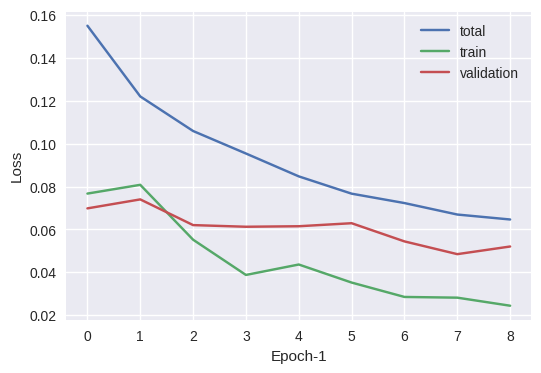

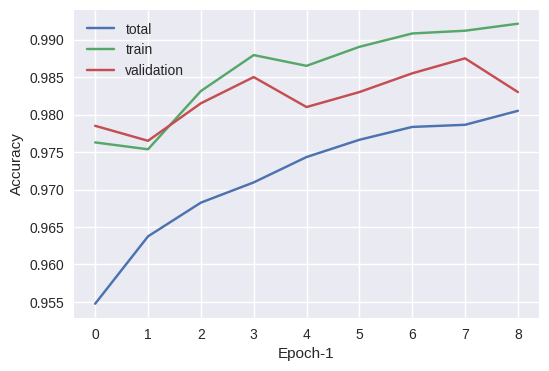

Model performance :
|            |      Loss |   Accuracy |   Test error rate [%] |
|------------+-----------+------------+-----------------------|
| Train      | 0.0282057 |   0.991183 |              0.881666 |
| Validation | 0.0484886 |   0.9875   |              1.25     |
| Test       | 0.0773252 |   0.979    |              2.1      |


In [35]:
# define model here
model = tf.keras.models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10),
    # softmax activation to transform output into probabilities
    layers.Activation('softmax')])

print(model.summary())

model.compile(
    # the recommended loss for a classification task is 'categorical_crossentropy'
    # (see lecture for details)
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']) # we use accuracy to quanitfy to network performance.

# define callbacks for training
save_best = tf.keras.callbacks.ModelCheckpoint(
    "checkpoints/best_model_{}.weights.h5".format(model.name),
    save_best_only=True,
    monitor="val_accuracy",
    save_weights_only=True,
)

# Keras calculates training accuracy and loss during the training and
# with regularization applied, while the validation metrics are calculated
# at the end of each epoch. This callback calculates the training metrics
# the same way as for the validation
class CalculateMetrics(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        train_loss, train_acc = model.evaluate(x_train, y_train_onehot, verbose=0)
        logs["train_loss"] = train_loss
        logs["train_acc"] = train_acc

results = model.fit(
    x_train, y_train_onehot,
    validation_data=(x_valid, y_valid_onehot),

    batch_size=32,
    epochs=10,
    callbacks=[
        save_best,
        CalculateMetrics(),
        tf.keras.callbacks.CSVLogger("checkpoints/history_{}.csv".format(model.name))
    ]
)

# load best model
model.load_weights(f"checkpoints/best_model_{model.name}.weights.h5")

# ------------------------
# ---     Plotting     ---
# ------------------------

# plot training history
history = np.genfromtxt(f"checkpoints/history_{model.name}.csv", delimiter=",", names=True)
# add plots below
loss = history["loss"][1:]
train_loss = history["train_loss"][1:]
test_loss = history["val_loss"][1:]

acc = history["accuracy"][1:]
train_acc = history["train_acc"][1:]
test_acc = history["val_accuracy"][1:]

# Plot loss over time
plt.figure(figsize=(6, 4))
plt.plot(loss, label="total")
plt.plot(train_loss,label="train")
plt.plot(test_loss,label="validation")
plt.legend()
plt.xlabel("Epoch-1")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(acc, label="total")
plt.plot(train_acc,label="train")
plt.plot(test_acc,label="validation")
plt.legend()
plt.xlabel("Epoch-1")
plt.ylabel("Accuracy")
plt.show()

# evaluate performance
print("Model performance :")
headers = ["", "Loss", "Accuracy", "Test error rate [%]"]

table = [
    [
        "Train",
        *model.evaluate(x_train, y_train_onehot, verbose=0, batch_size=128),
        (1 - model.evaluate(x_train, y_train_onehot, verbose=0, batch_size=128)[1])
        * 100,
    ],
    [
        "Validation",
        *model.evaluate(x_valid, y_valid_onehot, verbose=0, batch_size=128),
        (1 - model.evaluate(x_valid, y_valid_onehot, verbose=0, batch_size=128)[1])
        * 100,
    ],
    [
        "Test",
        *model.evaluate(x_test, y_test_onehot, verbose=0, batch_size=128),
        (1 - model.evaluate(x_test, y_test_onehot, verbose=0, batch_size=128)[1]) * 100,
    ],
]

print(tabulate(table, headers=headers, tablefmt="orgtbl"))

We have added two more hidden layers to the initial structure of the neural network. Now, the hidden layers have 128, 256 and 128 neurons, respectively. We include dropouts after each fully connected layer.

In this case, the validation loss does decrease during the epochs. However, there is still some generalization error. Anyways, we achieve a test accuracy of almost 98%, improving by 1% our previous result.

**Grid search**

Let's search the two hyperparameters dropout and number of nodes. We do it in the initial network with one hidden layer.



In [13]:
dropout_values = [0.2, 0.3, 0.5]
n_neurons_values = [64, 128, 256]
results_gridsearch = np.zeros((len(dropout_values), len(n_neurons_values), 2))
for iDrop, drop in enumerate(dropout_values):
  for iN, n_neurons in enumerate(n_neurons_values):
    model = tf.keras.models.Sequential([
                layers.Input(shape=(784,)),
                layers.Dense(n_neurons, activation='relu'),
                layers.Dropout(drop),
                layers.Dense(10),
                # softmax activation to transform output into probabilities
                layers.Activation('softmax')])

    model.compile(
        # the recommended loss for a classification task is 'categorical_crossentropy'
        # (see lecture for details)
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']) # we use accuracy to quanitfy to network performance.

    results = model.fit(
        x_train, y_train_onehot,
        validation_data=(x_valid, y_valid_onehot),
        batch_size=32,
        epochs=10,
        verbose=0
        )
    t = model.evaluate(x_test, y_test_onehot, verbose=0, batch_size=128)
    results_gridsearch[iDrop, iN] = t
    print(f"dropout = {drop:.2f}, {n_neurons} neurons -> accuracy {results_gridsearch[iDrop, iN][1]:.3f}, error rate = {100*(1-results_gridsearch[iDrop, iN][1]):.1f}%")

dropout = 0.20, 64 neurons -> accuracy 0.974, error rate = 2.6%
dropout = 0.20, 128 neurons -> accuracy 0.978, error rate = 2.2%
dropout = 0.20, 256 neurons -> accuracy 0.979, error rate = 2.1%
dropout = 0.30, 64 neurons -> accuracy 0.971, error rate = 2.9%
dropout = 0.30, 128 neurons -> accuracy 0.976, error rate = 2.4%
dropout = 0.30, 256 neurons -> accuracy 0.980, error rate = 2.0%
dropout = 0.50, 64 neurons -> accuracy 0.965, error rate = 3.5%
dropout = 0.50, 128 neurons -> accuracy 0.977, error rate = 2.3%
dropout = 0.50, 256 neurons -> accuracy 0.979, error rate = 2.1%


We see that the best accuracy is achieved with a **dropout of 0.3 and 256 neurons** in the hidden layer. 

However, the main difference in performance comes from the number of neurons in the hidden layer. More neurons (among the values 64, 128 and 256) means better performance. In general, the dropout of 0.2 gives the best result, even though the best combination includes 0.3 dropout.

**Random seach**

Now lets implement a random search. A random search allows us to scan more hyperparameters at once without more computing time. You can start from the template below.




In [14]:
N = 20 # number of trials
search = {
    'batch_size': np.random.choice([16, 32, 64, 128, 256], N),
    'num_neurons': np.random.choice([8, 32, 128, 256, 512], N),
    'learn_rate': np.random.choice([1e-5, 1e-4, 1e-3, 1e-2, 1e-1], N),
    'activation': np.random.choice(['relu', 'elu', 'sigmoid', 'tanh'], N),
    'dropout': np.random.choice([0.0, 0.1, 0.2, 0.3, 0.5, 0.6], N),
    'val_acc': np.zeros(N)
}

for i in range(N):
  # you can access the current value of the hyperparameter with `search['batch_size'][i]`
  model = model = tf.keras.models.Sequential([
                layers.Input(shape=(784,)),
                layers.Dense(int(search['num_neurons'][i]), activation=search['activation'][i]),
                layers.Dropout(search['dropout'][i]),
                layers.Dense(10),
                # softmax activation to transform output into probabilities
                layers.Activation('softmax')])
  model.compile(loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=search['learn_rate'][i]),
    metrics=['accuracy'])
  
  results = model.fit(
        x_train, y_train_onehot,
        validation_data=(x_valid, y_valid_onehot),
        batch_size=search['batch_size'][i],
        epochs=10,
        verbose=0
      )
  search['val_acc'][i] = model.evaluate(x_test, y_test_onehot, verbose=0, batch_size=128)[1]
  print(f"iteration {i}:")
  for key in search:
    print(f"\t{key}: {search[key][i]}")
  print(f"\t-> accuracy {search['val_acc'][i]:.3f}, error rate = {100*(1-search['val_acc'][i]):.1f}%")


iteration 0:
	batch_size: 256
	num_neurons: 256
	learn_rate: 0.1
	activation: relu
	dropout: 0.5
	val_acc: 0.6926249861717224
	-> accuracy 0.693, error rate = 30.7%
iteration 1:
	batch_size: 64
	num_neurons: 8
	learn_rate: 0.01
	activation: elu
	dropout: 0.0
	val_acc: 0.9257500171661377
	-> accuracy 0.926, error rate = 7.4%
iteration 2:
	batch_size: 16
	num_neurons: 512
	learn_rate: 0.1
	activation: sigmoid
	dropout: 0.3
	val_acc: 0.8878750205039978
	-> accuracy 0.888, error rate = 11.2%
iteration 3:
	batch_size: 16
	num_neurons: 8
	learn_rate: 0.0001
	activation: sigmoid
	dropout: 0.5
	val_acc: 0.8493750095367432
	-> accuracy 0.849, error rate = 15.1%
iteration 4:
	batch_size: 32
	num_neurons: 32
	learn_rate: 1e-05
	activation: elu
	dropout: 0.2
	val_acc: 0.8799999952316284
	-> accuracy 0.880, error rate = 12.0%
iteration 5:
	batch_size: 128
	num_neurons: 256
	learn_rate: 0.0001
	activation: elu
	dropout: 0.2
	val_acc: 0.9357500076293945
	-> accuracy 0.936, error rate = 6.4%
iteration

In [15]:
best_index = np.argmax(search['val_acc'])
print(f"Best hyperparameters:")
for key in search:
  print(f"\t{key}: {search[key][best_index]}")

Best hyperparameters:
	batch_size: 256
	num_neurons: 512
	learn_rate: 0.01
	activation: elu
	dropout: 0.6
	val_acc: 0.9679999947547913


The best hyperparameters found by random search are shown above. However, the accuracy is not better than the ones we found with a grid search. We randomply sampled the hyperparameter space, but apparently the batch size of 32, the learning rate of $1\times10^{-3}$ and the ReLU activation function were already good. Tuning the number of neurons in the hidden layer and the dropout gave better results than the random search in this case.

Finally, we will perform a grid search with different number of trials, in order to determine the optimal number of trials to find a good hyperparameter combination.

In [20]:
Ns = [2, 3, 5, 7]

mean_min_loss = []
std_min_loss = []
mean_max_acc = []
std_max_acc = []

for N in Ns:
  print(f"Running random search with N={N} trials")
  min_loss = np.array([])
  max_acc = np.array([])
  for j in range(3):
    search = {
        'batch_size': np.random.choice([16, 32, 64, 128, 256], N),
        'num_neurons': np.random.choice([8, 32, 128, 256, 512], N),
        'learn_rate': np.random.choice([1e-5, 1e-4, 1e-3, 1e-2, 1e-1], N),
        'activation': np.random.choice(['relu', 'elu', 'sigmoid', 'tanh'], N),
        'dropout': np.random.choice([0.0, 0.1, 0.2, 0.3, 0.5, 0.6], N),
        'val_loss': np.zeros(N),
        'val_acc': np.zeros(N)
    }
    for i in range(N):
      # you can access the current value of the hyperparameter with `search['batch_size'][i]`
      model = model = tf.keras.models.Sequential([
                    layers.Input(shape=(784,)),
                    layers.Dense(int(search['num_neurons'][i]), activation=search['activation'][i]),
                    layers.Dropout(search['dropout'][i]),
                    layers.Dense(10),
                    # softmax activation to transform output into probabilities
                    layers.Activation('softmax')])
      model.compile(loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=search['learn_rate'][i]),
        metrics=['accuracy'])
      
      results = model.fit(
            x_train, y_train_onehot,
            validation_data=(x_valid, y_valid_onehot),
            batch_size=search['batch_size'][i],
            epochs=10,
            verbose=0
          )
      search['val_loss'][i] = model.evaluate(x_test, y_test_onehot, verbose=0, batch_size=128)[0]
      search['val_acc'][i] = model.evaluate(x_test, y_test_onehot, verbose=0, batch_size=128)[1]
    
    min_loss = np.append(min_loss, np.min(search['val_loss']))
    max_acc = np.append(max_acc, np.max(search['val_acc']))
    print(f"\tRun {j+1}/3: min loss = {min_loss[-1]:.3f}, max acc = {max_acc[-1]:.3f}")

  mean_min_loss.append(np.mean(min_loss))
  std_min_loss.append(np.std(min_loss))
  mean_max_acc.append(np.mean(max_acc))
  std_max_acc.append(np.std(max_acc))

  print(f"\nmean min loss = {mean_min_loss[-1]:.3f} ± {std_min_loss[-1]:.3f}")
  print(f"mean max acc = {mean_max_acc[-1]:.3f} ± {std_max_acc[-1]:.3f}")
  print("-" * 50)

Running random search with N=2 trials
	Run 1/3: min loss = 0.915, max acc = 0.928
	Run 2/3: min loss = 0.358, max acc = 0.902
	Run 3/3: min loss = 0.188, max acc = 0.947

mean min loss = 0.487 ± 0.310
mean max acc = 0.926 ± 0.018
--------------------------------------------------
Running random search with N=3 trials
	Run 1/3: min loss = 0.086, max acc = 0.973
	Run 2/3: min loss = 0.357, max acc = 0.906
	Run 3/3: min loss = 0.084, max acc = 0.974

mean min loss = 0.175 ± 0.128
mean max acc = 0.951 ± 0.032
--------------------------------------------------
Running random search with N=5 trials
	Run 1/3: min loss = 0.201, max acc = 0.960
	Run 2/3: min loss = 0.080, max acc = 0.976
	Run 3/3: min loss = 0.116, max acc = 0.966

mean min loss = 0.132 ± 0.051
mean max acc = 0.967 ± 0.007
--------------------------------------------------
Running random search with N=7 trials
	Run 1/3: min loss = 0.095, max acc = 0.975
	Run 2/3: min loss = 0.138, max acc = 0.963
	Run 3/3: min loss = 0.084, max

In [23]:
Ns = [10, 15]

for N in Ns:
  print(f"Running random search with N={N} trials")
  min_loss = np.array([])
  max_acc = np.array([])
  for j in range(3):
    search = {
        'batch_size': np.random.choice([16, 32, 64, 128, 256], N),
        'num_neurons': np.random.choice([8, 32, 128, 256, 512], N),
        'learn_rate': np.random.choice([1e-5, 1e-4, 1e-3, 1e-2, 1e-1], N),
        'activation': np.random.choice(['relu', 'elu', 'sigmoid', 'tanh'], N),
        'dropout': np.random.choice([0.0, 0.1, 0.2, 0.3, 0.5, 0.6], N),
        'val_loss': np.zeros(N),
        'val_acc': np.zeros(N)
    }
    for i in range(N):
      # you can access the current value of the hyperparameter with `search['batch_size'][i]`
      model = model = tf.keras.models.Sequential([
                    layers.Input(shape=(784,)),
                    layers.Dense(int(search['num_neurons'][i]), activation=search['activation'][i]),
                    layers.Dropout(search['dropout'][i]),
                    layers.Dense(10),
                    # softmax activation to transform output into probabilities
                    layers.Activation('softmax')])
      model.compile(loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=search['learn_rate'][i]),
        metrics=['accuracy'])
      
      results = model.fit(
            x_train, y_train_onehot,
            validation_data=(x_valid, y_valid_onehot),
            batch_size=search['batch_size'][i],
            epochs=10,
            verbose=0
          )
      search['val_loss'][i] = model.evaluate(x_test, y_test_onehot, verbose=0, batch_size=128)[0]
      search['val_acc'][i] = model.evaluate(x_test, y_test_onehot, verbose=0, batch_size=128)[1]
    
    min_loss = np.append(min_loss, np.min(search['val_loss']))
    max_acc = np.append(max_acc, np.max(search['val_acc']))
    print(f"\tRun {j+1}/3: min loss = {min_loss[-1]:.3f}, max acc = {max_acc[-1]:.3f}")

  mean_min_loss.append(np.mean(min_loss))
  std_min_loss.append(np.std(min_loss))
  mean_max_acc.append(np.mean(max_acc))
  std_max_acc.append(np.std(max_acc))

  print(f"\nmean min loss = {mean_min_loss[-1]:.3f} ± {std_min_loss[-1]:.3f}")
  print(f"mean max acc = {mean_max_acc[-1]:.3f} ± {std_max_acc[-1]:.3f}")

Running random search with N=10 trials
	Run 1/3: min loss = 0.067, max acc = 0.979
	Run 2/3: min loss = 0.075, max acc = 0.977
	Run 3/3: min loss = 0.080, max acc = 0.981

mean min loss = 0.074 ± 0.005
mean max acc = 0.979 ± 0.002
Running random search with N=15 trials
	Run 1/3: min loss = 0.089, max acc = 0.978
	Run 2/3: min loss = 0.092, max acc = 0.971
	Run 3/3: min loss = 0.090, max acc = 0.972

mean min loss = 0.090 ± 0.001
mean max acc = 0.974 ± 0.003


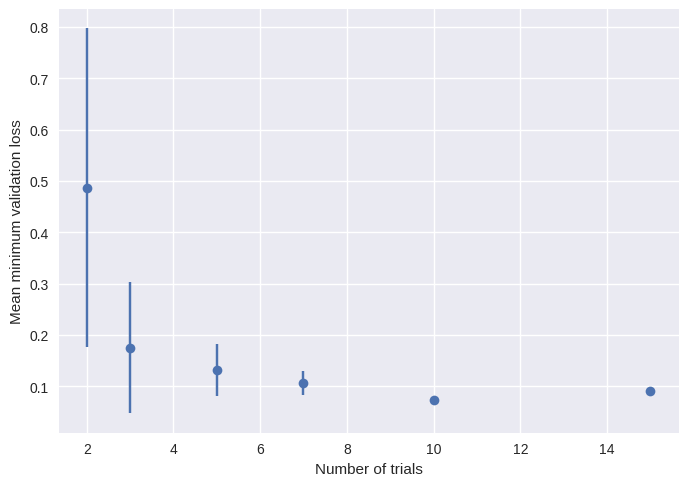

In [28]:
Ns = [2, 3, 5, 7, 10, 15]

plt.errorbar(Ns, mean_min_loss, yerr=std_min_loss, label="min loss", fmt="o")
plt.xlabel("Number of trials")
plt.ylabel("Mean minimum validation loss");

With a small number of trials (2, 3), the variance of the minimum validation loss is big. You can find a good combination of hyperparameters, but you can as well not find it. 5 and 7 trials are already more stable. In the case of 10 and 15 trials, the minimum validation loss is very precise. One might expect that the minimum validation loss would always increase with the number of trials, but we see that for 10 and 15 trials, the results are very similar. This means that around 10 trials are enough to find good hyperparameters, and more computing time than that is not that worth it.